In [1]:
import pandas as pd



## 1. data understanding

In [2]:
from pathlib import Path

downloads = Path.home() / "Downloads"
list(downloads.iterdir())

[WindowsPath('C:/Users/tasmiya/Downloads/1) iris.csv'),
 WindowsPath('C:/Users/tasmiya/Downloads/2) Stock Prices Data Set.csv'),
 WindowsPath('C:/Users/tasmiya/Downloads/217aeed7-7316-4a7b-aa65-4d658687ffd4 (1).png'),
 WindowsPath('C:/Users/tasmiya/Downloads/217aeed7-7316-4a7b-aa65-4d658687ffd4.png'),
 WindowsPath('C:/Users/tasmiya/Downloads/30 Day - SQL Practice Files- SD50 (1).zip'),
 WindowsPath('C:/Users/tasmiya/Downloads/30 Day - SQL Practice Files- SD50.zip'),
 WindowsPath('C:/Users/tasmiya/Downloads/Accounts-Payable.xlsx'),
 WindowsPath('C:/Users/tasmiya/Downloads/ai trading.ipynb'),
 WindowsPath('C:/Users/tasmiya/Downloads/aiproject.ipynb'),
 WindowsPath('C:/Users/tasmiya/Downloads/amazon prime data.sql'),
 WindowsPath('C:/Users/tasmiya/Downloads/Anaconda3-2025.12-2-Windows-x86_64 (1).exe'),
 WindowsPath('C:/Users/tasmiya/Downloads/archive'),
 WindowsPath('C:/Users/tasmiya/Downloads/archive.zip'),
 WindowsPath('C:/Users/tasmiya/Downloads/Aspiring data analyst in a digital world

In [3]:
archive = Path.home() / "Downloads" / "archive"
list(archive.iterdir())

[WindowsPath('C:/Users/tasmiya/Downloads/archive/PS_20174392719_1491204439457_log.csv')]

In [4]:
import pandas as pd

file_path = Path.home() / "Downloads" / "archive" / "PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(file_path, nrows=10000)

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.shape

(10000, 11)

In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            10000 non-null  int64  
 1   type            10000 non-null  object 
 2   amount          10000 non-null  float64
 3   nameOrig        10000 non-null  object 
 4   oldbalanceOrg   10000 non-null  float64
 5   newbalanceOrig  10000 non-null  float64
 6   nameDest        10000 non-null  object 
 7   oldbalanceDest  10000 non-null  float64
 8   newbalanceDest  10000 non-null  float64
 9   isFraud         10000 non-null  int64  
 10  isFlaggedFraud  10000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 859.5+ KB


In [8]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,10000.000000,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,10000.0
mean,4.178900,1.035467e+05,8.939330e+05,9.152741e+05,9.342758e+05,1.096606e+06,0.006800,0.0
std,2.479821,2.663072e+05,2.135683e+06,2.181428e+06,2.676340e+06,3.014496e+06,0.082185,0.0
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,1.000000,4.397530e+03,1.276875e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,5.000000,1.285874e+04,2.137556e+04,1.034994e+04,0.000000e+00,0.000000e+00,0.000000,0.0
75%,7.000000,1.143825e+05,1.782719e+05,1.760934e+05,2.831067e+05,2.520552e+05,0.000000,0.0
max,7.000000,1.000000e+07,1.293042e+07,1.301050e+07,1.951612e+07,1.916920e+07,1.000000,0.0


## 2. Data Cleaning & Quality Check

### 2.1 Missing Values Check

In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

### 2.2 duplicate value

In [10]:
df.duplicated().sum()

np.int64(0)

### 2.3 Transaction Type Validation

In [11]:
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

### 2.4 unique transaction type

In [12]:
df['type'].value_counts()

type
PAYMENT     5465
CASH_IN     1949
CASH_OUT    1321
TRANSFER     921
DEBIT        344
Name: count, dtype: int64

## 3.fraud analysis

### 3.1 Fraud vs Non-Fraud Transactions

In [13]:
df['isFraud'].value_counts()

isFraud
0    9932
1      68
Name: count, dtype: int64

### 3.2 fraud transaction percentage

In [14]:
df['isFraud'].mean()*100

np.float64(0.6799999999999999)

In [15]:
df.to_csv("paysim_test_10000.csv", index=False)

In [16]:
import os
os.path.exists("paysim_test_10000.csv")

True

In [17]:
import os
os.getcwd()

'C:\\Users\\tasmiya\\Contacts'

In [18]:
os.path.abspath("paysim_test_10000.csv")

'C:\\Users\\tasmiya\\Contacts\\paysim_test_10000.csv'

## 4. EDA & Visualization

### 4.1 transaction type distribution

In [19]:
type_counts = df['type'].value_counts()

type_counts

type
PAYMENT     5465
CASH_IN     1949
CASH_OUT    1321
TRANSFER     921
DEBIT        344
Name: count, dtype: int64

### 4.2 visualize transaction type

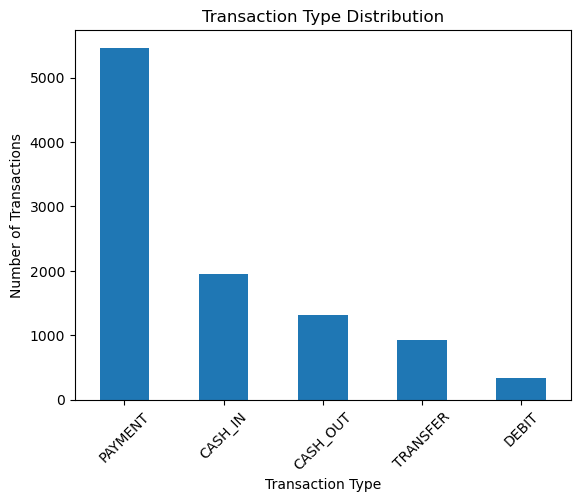

In [20]:
import matplotlib.pyplot as plt

type_counts.plot(kind='bar')

plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

### 4.3 Transaction Amount Distribution

In [21]:
df['amount'].describe()

count    1.000000e+04
mean     1.035467e+05
std      2.663072e+05
min      2.390000e+00
25%      4.397530e+03
50%      1.285874e+04
75%      1.143825e+05
max      1.000000e+07
Name: amount, dtype: float64

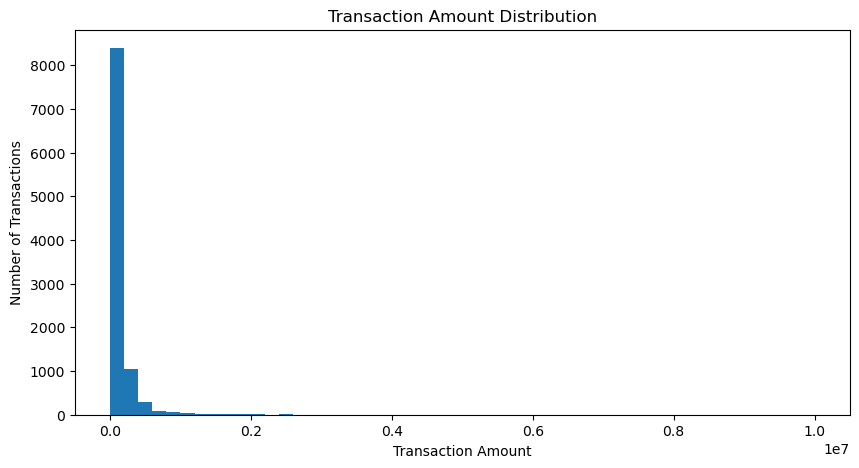

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df['amount'], bins=50)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Number of Transactions')

plt.show()

### 4.4 Flagged Fraud Distribution

In [23]:
flagged_counts = df['isFlaggedFraud'].value_counts()

flagged_counts

isFlaggedFraud
0    10000
Name: count, dtype: int64

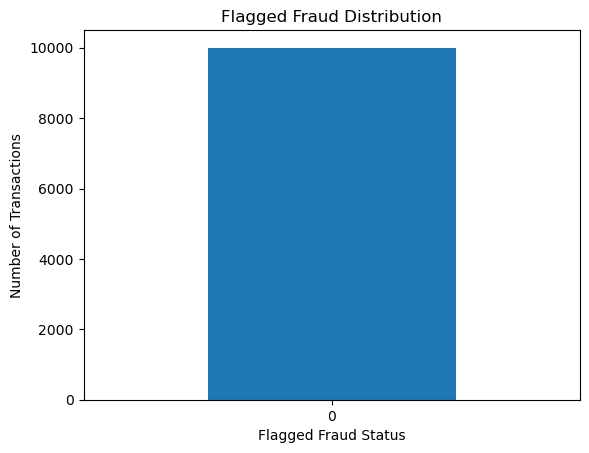

In [24]:
import matplotlib.pyplot as plt

flagged_counts.plot(kind='bar')

plt.title('Flagged Fraud Distribution')
plt.xlabel('Flagged Fraud Status')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

## 5. Bivariate Analysis

### 5.1 Transaction Type vs Transaction Amount

In [25]:
avg_amount_by_type = df.groupby('type')['amount'].mean().sort_values(ascending=False)

avg_amount_by_type

type
TRANSFER    471654.518914
CASH_OUT    173507.343543
CASH_IN     168041.492468
PAYMENT       7891.430867
DEBIT         3576.593721
Name: amount, dtype: float64

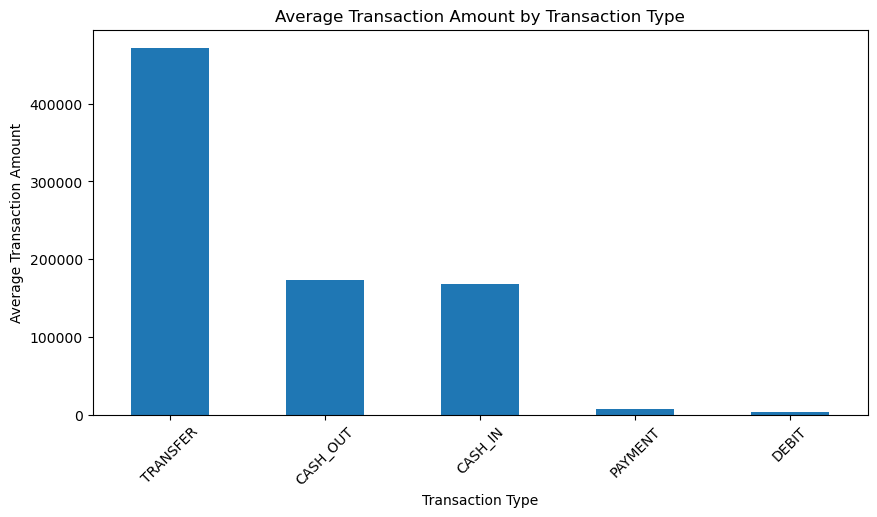

In [26]:
import matplotlib.pyplot as plt

avg_amount_by_type.plot(kind='bar', figsize=(10, 5))

plt.title('Average Transaction Amount by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=45)
plt.show()

### 5.2 Transaction Type vs Fraud

In [27]:
fraud_by_type = df[df['isFraud'] == 1].groupby('type').size().sort_values(ascending=False)

fraud_by_type

type
CASH_OUT    35
TRANSFER    33
dtype: int64

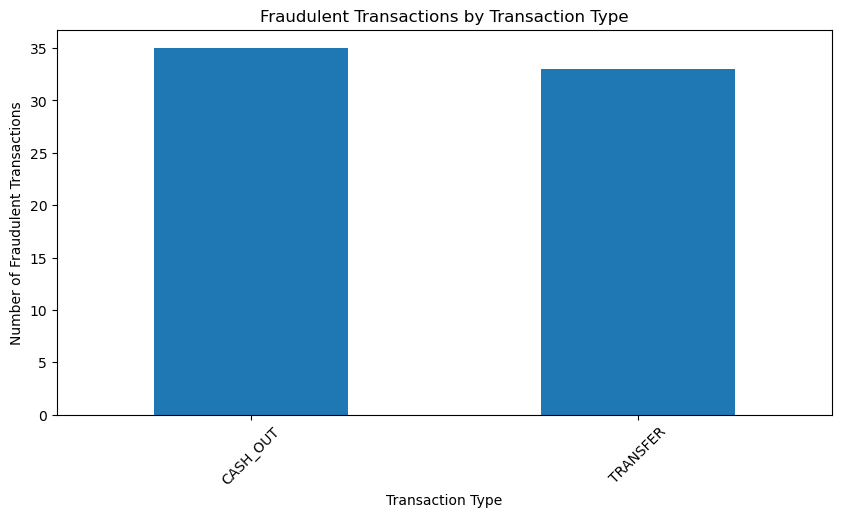

In [28]:
import matplotlib.pyplot as plt

fraud_by_type.plot(kind='bar', figsize=(10, 5))

plt.title('Fraudulent Transactions by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45)
plt.show()

### 5.3 Fraud vs Transaction Amount

In [29]:
Fraud_amount_comparison = df.groupby('isFraud')['amount'].mean()

Fraud_amount_comparison

isFraud
0    100603.239233
1    533463.638676
Name: amount, dtype: float64

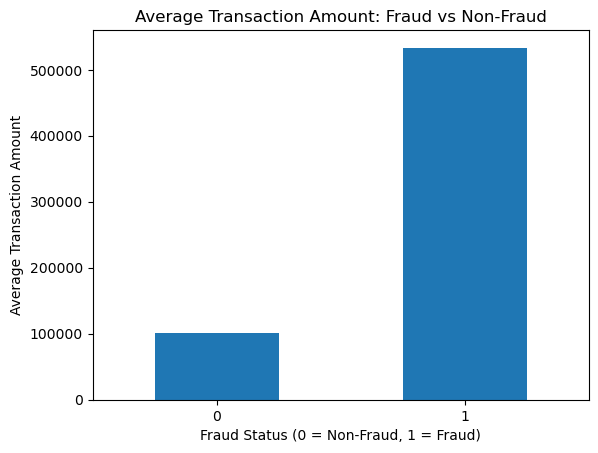

In [30]:
import matplotlib.pyplot as plt

Fraud_amount_comparison.plot(kind='bar')

plt.title('Average Transaction Amount: Fraud vs Non-Fraud')
plt.xlabel('Fraud Status (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=0)
plt.show()

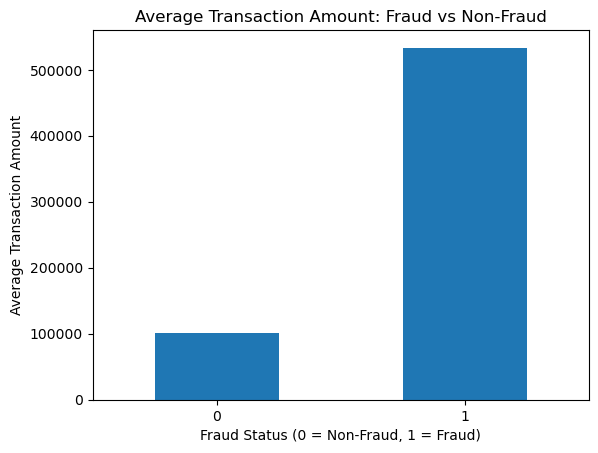

In [31]:
import matplotlib.pyplot as plt

Fraud_amount_comparison.plot(kind='bar')

plt.title('Average Transaction Amount: Fraud vs Non-Fraud')
plt.xlabel('Fraud Status (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=0)

plt.show()

In [32]:
Fraud_sender_balance = df.groupby('isFraud')['oldbalanceOrg'].mean()

Fraud_sender_balance

isFraud
0    896160.769435
1    568552.955588
Name: oldbalanceOrg, dtype: float64

### 5.4 Fraud vs Sender Balance

In [33]:
fraud_sender_balance = df.groupby('isFraud')['oldbalanceOrg'].mean()

fraud_sender_balance

isFraud
0    896160.769435
1    568552.955588
Name: oldbalanceOrg, dtype: float64

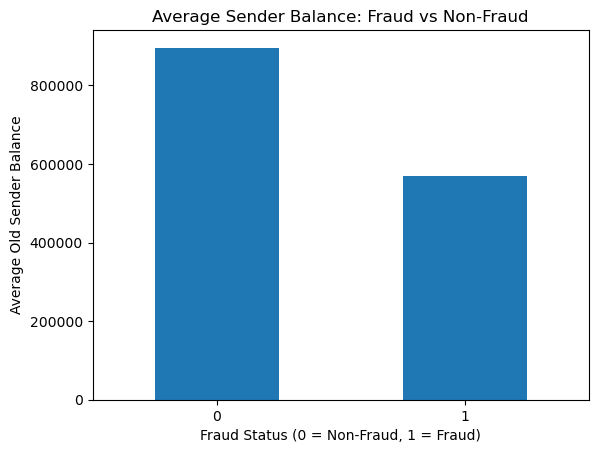

In [34]:
import matplotlib.pyplot as plt

fraud_sender_balance.plot(kind='bar')

plt.title('Average Sender Balance: Fraud vs Non-Fraud')
plt.xlabel('Fraud Status (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Average Old Sender Balance')
plt.xticks(rotation=0)

plt.show()

### 5.5 Fraud vs New Sender Balance

In [35]:
fraud_new_sender_balance = df.groupby('isFraud')['newbalanceOrig'].mean()

fraud_new_sender_balance

isFraud
0    921245.524515
1     43094.388824
Name: newbalanceOrig, dtype: float64

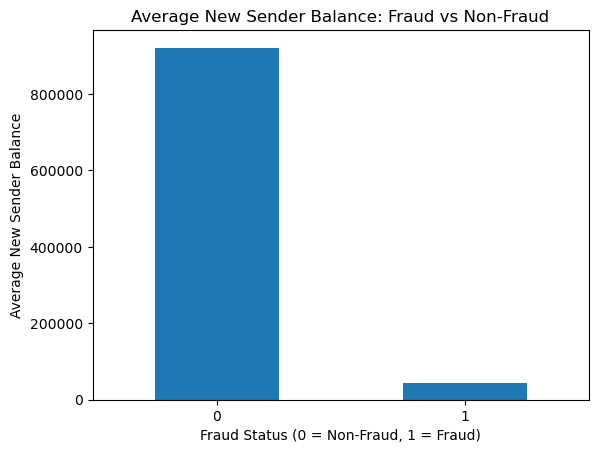

In [36]:
import matplotlib.pyplot as plt

fraud_new_sender_balance.plot(kind='bar')

plt.title('Average New Sender Balance: Fraud vs Non-Fraud')
plt.xlabel('Fraud Status (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Average New Sender Balance')
plt.xticks(rotation=0)

plt.show()

### 5.6 Fraud Rate by Transaction Type

In [37]:
fraud_rate_by_type = df.groupby('type')['isFraud'].mean() * 100

fraud_rate_by_type.sort_values(ascending=False)

type
TRANSFER    3.583062
CASH_OUT    2.649508
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

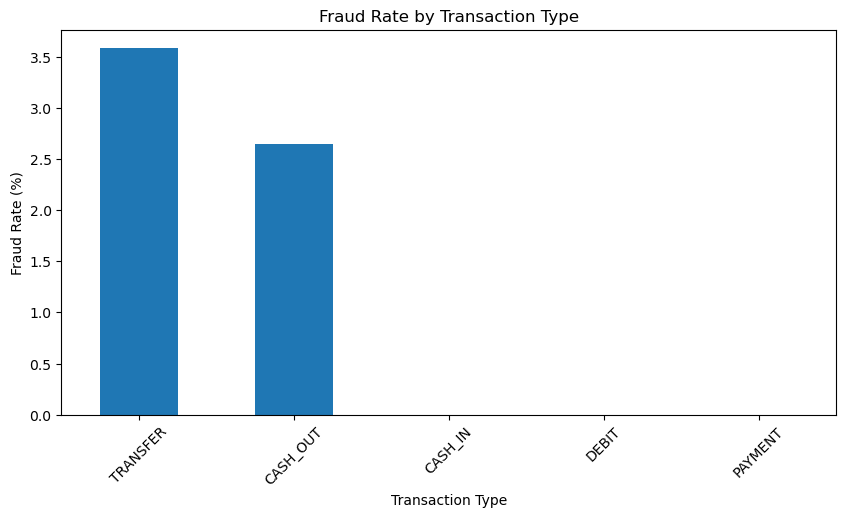

In [38]:
import matplotlib.pyplot as plt

fraud_rate_by_type.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)

plt.show()

### 5.7 Fraud vs Transaction Amount — Distribution

In [39]:
fraud_data = df[df['isFraud'] == 1]['amount']
non_fraud_data = df[df['isFraud'] == 0]['amount']

fraud_data.describe(), non_fraud_data.describe()

(count    6.800000e+01
 mean     5.334636e+05
 std      1.753539e+06
 min      1.810000e+02
 25%      1.494984e+04
 50%      2.864476e+04
 75%      1.815618e+05
 max      1.000000e+07
 Name: amount, dtype: float64,
 count    9.932000e+03
 mean     1.006032e+05
 std      2.222295e+05
 min      2.390000e+00
 25%      4.372755e+03
 50%      1.274065e+04
 75%      1.140599e+05
 max      3.776389e+06
 Name: amount, dtype: float64)

C:\Users\tasmiya\AppData\Local\Temp\ipykernel_3816\3991337131.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


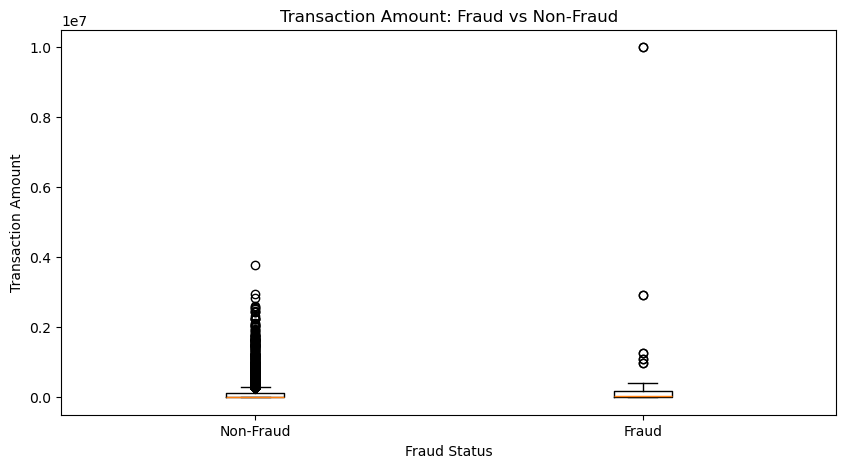

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.boxplot(
    [non_fraud_data, fraud_data],
    labels=['Non-Fraud', 'Fraud']
)

plt.title('Transaction Amount: Fraud vs Non-Fraud')
plt.xlabel('Fraud Status')
plt.ylabel('Transaction Amount')

plt.show()

### 5.8 Sender Balance Difference

In [41]:
df['sender_balance_change'] = (
    df['oldbalanceOrg'] - df['newbalanceOrig']
)

df['sender_balance_change'].describe()

count    1.000000e+04
mean    -2.134106e+04
std      1.805159e+05
min     -1.030100e+06
25%      0.000000e+00
50%      5.488050e+02
75%      5.831355e+03
max      1.000000e+07
Name: sender_balance_change, dtype: float64

In [42]:
balance_change_fraud = df.groupby('isFraud')['sender_balance_change'].mean()

balance_change_fraud

isFraud
0    -25084.755080
1    525458.566765
Name: sender_balance_change, dtype: float64

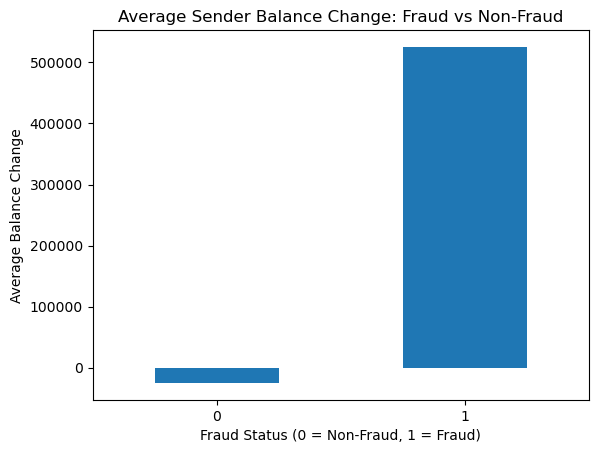

In [43]:
import matplotlib.pyplot as plt

balance_change_fraud.plot(kind='bar')

plt.title('Average Sender Balance Change: Fraud vs Non-Fraud')
plt.xlabel('Fraud Status (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Average Balance Change')
plt.xticks(rotation=0)

plt.show()

### 5.9 Transaction Amount vs Fraud

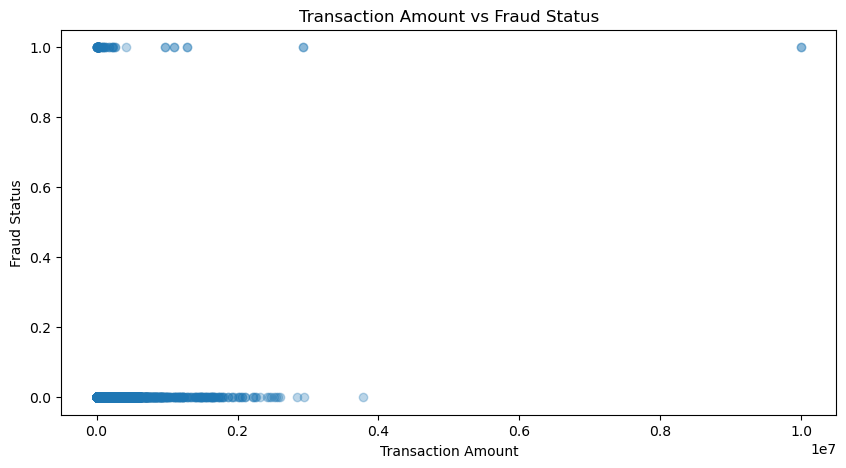

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(
    df['amount'],
    df['isFraud'],
    alpha=0.3
)

plt.title('Transaction Amount vs Fraud Status')
plt.xlabel('Transaction Amount')
plt.ylabel('Fraud Status')

plt.show()

### 5.10 Correlation Analysis

In [45]:
numeric_columns = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'isFraud'
]

correlation = df[numeric_columns].corr()

correlation

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,0.123194,0.089860,0.347842,0.412863,0.133586
oldbalanceOrg,0.123194,1.000000,0.996727,0.228128,0.198181,-0.012607
newbalanceOrig,0.089860,0.996727,1.000000,0.236321,0.202469,-0.033084
oldbalanceDest,0.347842,0.228128,0.236321,1.000000,0.944481,-0.021004
newbalanceDest,0.412863,0.198181,0.202469,0.944481,1.000000,-0.010887
isFraud,0.133586,-0.012607,-0.033084,-0.021004,-0.010887,1.000000


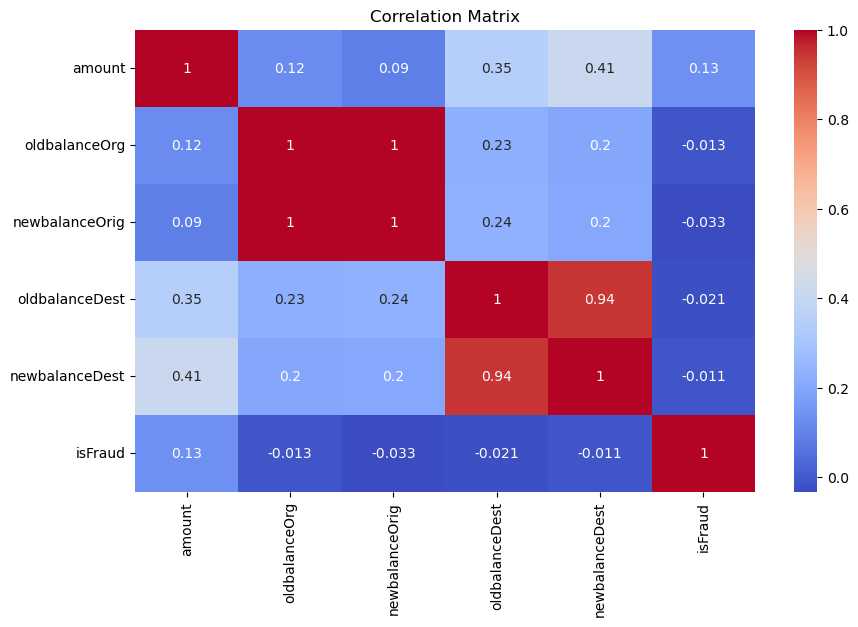

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

## 6 Advanced Fraud Analysis

### 6.1 Fraud Percentage by Transaction Type

In [47]:
fraud_percentage = pd.crosstab(
    df['type'],
    df['isFraud'],
    normalize='index'
) * 100

fraud_percentage

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,97.350492,2.649508
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,96.416938,3.583062


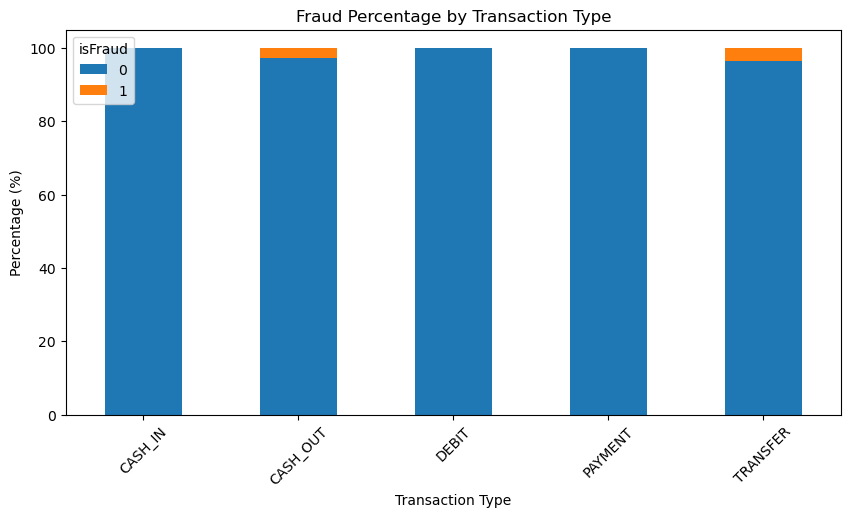

In [48]:
fraud_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.title('Fraud Percentage by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)

plt.show()

### 6.2 High-Value Transactions

In [49]:
high_value_threshold = df['amount'].quantile(0.90)

high_value_threshold

np.float64(284452.178)

In [50]:
high_value_transactions = df[
    df['amount'] > high_value_threshold
]

high_value_transactions.shape

(1000, 12)

In [51]:
high_value_fraud = df[
    (df['amount'] > high_value_threshold) &
    (df['isFraud'] == 1)
]

high_value_fraud.shape

(11, 12)

In [52]:
high_value_fraud_percentage = (
    len(high_value_fraud) /
    len(high_value_transactions)
) * 100

high_value_fraud_percentage

1.0999999999999999

### 6.3Actual Fraud vs Flagged Fraud

In [53]:
actual_fraud = df['isFraud'].sum()

flagged_fraud = df['isFlaggedFraud'].sum()

actual_fraud, flagged_fraud

(np.int64(68), np.int64(0))

In [54]:
fraud_comparison = pd.DataFrame({
    'Category': ['Actual Fraud', 'System Flagged Fraud'],
    'Count': [actual_fraud, flagged_fraud]
})

fraud_comparison

,Category,Count
0,Actual Fraud,68
1,System Flagged Fraud,0


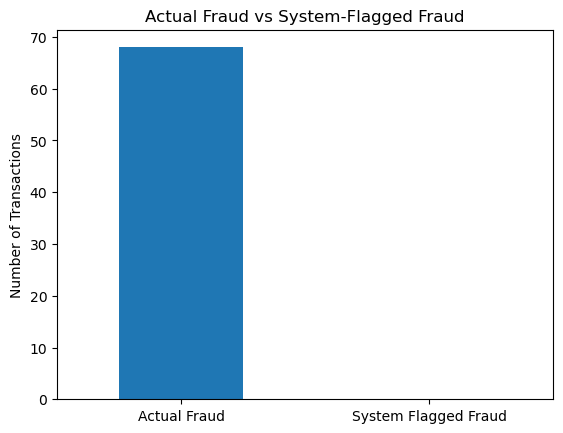

In [55]:
fraud_comparison.plot(
    x='Category',
    y='Count',
    kind='bar',
    legend=False
)

plt.title('Actual Fraud vs System-Flagged Fraud')
plt.xlabel('')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

plt.show()

In [56]:
transaction_volume = df.groupby('type').size()

fraud_volume = df[
    df['isFraud'] == 1
].groupby('type').size()

transaction_volume, fraud_volume

(type
 CASH_IN     1949
 CASH_OUT    1321
 DEBIT        344
 PAYMENT     5465
 TRANSFER     921
 dtype: int64,
 type
 CASH_OUT    35
 TRANSFER    33
 dtype: int64)

In [57]:
type_analysis = pd.DataFrame({
    'Total Transactions': transaction_volume,
    'Fraud Transactions': fraud_volume
}).fillna(0)

type_analysis['Fraud Rate (%)'] = (
    type_analysis['Fraud Transactions'] /
    type_analysis['Total Transactions']
) * 100

type_analysis.sort_values(
    'Fraud Rate (%)',
    ascending=False
)

,Total Transactions,Fraud Transactions,Fraud Rate (%)
type,,,
TRANSFER,921,33.0,3.583062
CASH_OUT,1321,35.0,2.649508
CASH_IN,1949,0.0,0.000000
DEBIT,344,0.0,0.000000
PAYMENT,5465,0.0,0.000000



## 7. Business Insights

1. Payment transactions represent the highest transaction volume in the dataset.

2. Cash-out transactions account for the highest number of fraudulent transactions.

3. Fraudulent transactions have significantly higher average transaction amounts than non-fraudulent transactions.

4. High-value transactions require additional monitoring because transaction amount can be an important fraud indicator.

5. Fraud rates vary across transaction types, indicating that some transaction categories may require stronger fraud controls.

6. The comparison between actual fraud and system-flagged fraud helps evaluate the effectiveness of the existing fraud detection mechanism.

7. Sender balance changes provide an additional feature for identifying potentially suspicious transactions.

## 8. Business Recommendations

### 1. Monitor High-Value Transactions
Financial institutions should apply additional verification or monitoring to unusually high-value transactions.

### 2. Strengthen Cash-Out Monitoring
Since cash-out transactions show a high level of fraudulent activity, additional fraud detection rules can be applied to this transaction type.

### 3. Use Transaction-Type-Specific Rules
Fraud detection thresholds should not be identical for every transaction type. Risk levels can differ by transaction category.

### 4. Monitor Sender Balance Changes
Large or unusual changes in sender balances can be used as an additional fraud detection signal.

### 5. Improve System Flagging
Actual fraud should be compared with system-flagged transactions regularly to identify potential gaps in automated fraud detection.

### 6. Develop Risk-Based Monitoring
Transactions can be assigned risk scores using transaction amount, transaction type, balance changes and historical transaction behavior.

## 9. Project Summary

This project analyzes financial transactions from the PaySim dataset to identify patterns associated with fraudulent activity.

The analysis was performed using Python, Pandas, NumPy, Matplotlib and Seaborn. SQL was used in PostgreSQL for structured fraud analysis.

The project examined transaction volumes, transaction amounts, fraud patterns, transaction types, sender balances, high-value transactions and system-flagged fraud.

The findings can help financial organizations improve transaction monitoring and develop more effective fraud detection strategies.

In [58]:
df.to_csv(
    r"C:\Users\tasmiya\Downloads\paysim_dashboard.csv",
    index=False
)

In [59]:
df.to_csv("paysim_dashboard.csv", index=False)

In [60]:
df.shape

(10000, 12)

In [61]:
df.to_csv("paysim_dashboard.csv", index=False)